In [1]:
import libraries as lb

In [2]:
consumption_data=lb.pd.read_csv("Dataset/consumption_facility_cleaned.csv")
consumption_data.head()

,Patient_ID,Region,Medicine_ID,DrugName,Daily_Consumption_Units,Out_of_Stock_Days,Wastage_Units,Bed_Days,Supplies_Used,Total_Consumption,Stockout_Flag,Wastage_Flag,Consumption_per_Bed
0,P001,Indore,M07208F17,LIGNOCAINE HYDROCHLORIDE 2% INJ,0.5,0,0,2,"Gloves, IV",1.0,False,False,0.5
1,P001,Indore,M09598F70,ADRENALINE INJ 1ML,2.0,0,0,2,"Gloves, IV",4.0,False,False,2.0
2,P001,Indore,M359D09B5,LIQUID PARAFFIN 100ML,0.0,0,1,2,"Gloves, IV",0.0,False,True,0.0
3,P001,Indore,M524E5E35,ESOMEPRAZOLE 40MG,0.5,0,0,2,"Gloves, IV",1.0,False,False,0.5
4,P001,Indore,M589A5AA4,WATER FOR INJECTION 10ML SOLUTION,3.0,0,0,2,"Gloves, IV",6.0,False,False,3.0


In [3]:
consumption_data['Stockout_Flag'] = (consumption_data['Out_of_Stock_Days'] > 0).astype(int)
consumption_data['Wastage_Flag'] = (consumption_data['Wastage_Units'] > 0).astype(int)

print("Columns and dtypes:")
print(consumption_data.dtypes)
print("\nShape:", consumption_data.shape)
print("\nCategorical columns:")
print(consumption_data.select_dtypes(include='object').columns.tolist())
print("\nNumerical columns:")
print(consumption_data.select_dtypes(include=['int64','float64']).columns.tolist())


Columns and dtypes:
Patient_ID                  object
Region                      object
Medicine_ID                 object
DrugName                    object
Daily_Consumption_Units    float64
Out_of_Stock_Days            int64
Wastage_Units                int64
Bed_Days                     int64
Supplies_Used               object
Total_Consumption          float64
Stockout_Flag                int64
Wastage_Flag                 int64
Consumption_per_Bed        float64
dtype: object

Shape: (11111, 13)

Categorical columns:
['Patient_ID', 'Region', 'Medicine_ID', 'DrugName', 'Supplies_Used']

Numerical columns:
['Daily_Consumption_Units', 'Out_of_Stock_Days', 'Wastage_Units', 'Bed_Days', 'Total_Consumption', 'Stockout_Flag', 'Wastage_Flag', 'Consumption_per_Bed']


# Linear Regression

In [4]:
consumption_ml = consumption_data.drop(columns=[
    'Patient_ID',
    'Medicine_ID',
    
    'Consumption_per_Bed',
])

print("After dropping:")
print(consumption_ml.shape)
print(consumption_ml.columns.tolist())


After dropping:
(11111, 10)
['Region', 'DrugName', 'Daily_Consumption_Units', 'Out_of_Stock_Days', 'Wastage_Units', 'Bed_Days', 'Supplies_Used', 'Total_Consumption', 'Stockout_Flag', 'Wastage_Flag']


In [5]:
import numpy as np

# Feature Engineering
consumption_ml['Wastage_Rate'] = (
    consumption_ml['Wastage_Units'] /
    (consumption_ml['Daily_Consumption_Units'] + 1)
)

consumption_ml['Consumption_Efficiency'] = (
    consumption_ml['Daily_Consumption_Units'] /
    (consumption_ml['Wastage_Units'] + 1)
)

consumption_ml['Stock_Impact'] = (
    consumption_ml['Out_of_Stock_Days'] *
    consumption_ml['Stockout_Flag']
)

consumption_ml['Wastage_Severity'] = (
    consumption_ml['Wastage_Units'] *
    consumption_ml['Wastage_Flag']
)

# Wastage_Rate - Measures wastage relative to daily consumption.
# Consumption_Efficiency - Shows how efficiently consumption happens compared to wastage.
# Stock_Impact - Captures combined effect of stockout days and stockout events.
# Wastage_Severity - Represents weighted wastage based on whether wastage occurred.
print(consumption_ml.head())

   Region                            DrugName  Daily_Consumption_Units  \
0  Indore     LIGNOCAINE HYDROCHLORIDE 2% INJ                      0.5   
1  Indore                  ADRENALINE INJ 1ML                      2.0   
2  Indore               LIQUID PARAFFIN 100ML                      0.0   
3  Indore                   ESOMEPRAZOLE 40MG                      0.5   
4  Indore   WATER FOR INJECTION 10ML SOLUTION                      3.0   

   Out_of_Stock_Days  Wastage_Units  Bed_Days Supplies_Used  \
0                  0              0         2    Gloves, IV   
1                  0              0         2    Gloves, IV   
2                  0              1         2    Gloves, IV   
3                  0              0         2    Gloves, IV   
4                  0              0         2    Gloves, IV   

   Total_Consumption  Stockout_Flag  Wastage_Flag  Wastage_Rate  \
0                1.0              0             0           0.0   
1                4.0              0       

# Label Encoding

In [6]:
le6 = lb.LabelEncoder()
consumption_ml['Supplies_Used'] = le6.fit_transform(consumption_data['Supplies_Used'])

In [7]:
le = lb.LabelEncoder()
cols = ['Region', 'DrugName', 'Supplies_Used']

for col in cols:
    consumption_ml[col] = le.fit_transform(consumption_ml[col])

    print(f"\n{col} encoded:")
    print(consumption_ml[col].value_counts())

    print(f"\n{col} mapping:")
    for i, category in enumerate(le.classes_):
        print(f"{category} → {i}")


Region encoded:
Region
13    1394
7      933
3      854
12     728
0      699
16     699
11     685
5      683
1      664
8      662
14     623
9      554
6      426
4      423
18     275
15     230
2      227
10     178
17     174
Name: count, dtype: int64

Region mapping:
Ahmedabad → 0
Bangalore → 1
Bhubaneswar → 2
Chennai → 3
Coimbatore → 4
Delhi → 5
Guwahati → 6
Hyderabad → 7
Indore → 8
Jaipur → 9
Kanpur → 10
Kolkata → 11
Lucknow → 12
Mumbai → 13
Nagpur → 14
Patna → 15
Pune → 16
Raipur → 17
Surat → 18

DrugName encoded:
DrugName
0      577
654    407
479    325
659    310
544    304
      ... 
388      1
197      1
469      1
590      1
203      1
Name: count, Length: 752, dtype: int64

DrugName mapping:
  → 0
 ACEBROPHYLLINE 100MG CAP → 1
 ACEBROPHYLLINE 200MG TAB → 2
 ACECLOFENAC 100MG + PARACETAMOL 325MG + SERRATIOPEPTIDASE 15MG TAB → 3
 ACECLOFENAC 100MG + PARACETAMOL 325MG TAB → 4
 ACYCLOVIR 200MG TAB → 5
 ACYCLOVIR 250MG INJ → 6
 ACYCLOVIR 400MG TAB → 7
 ADEMETIONINE 400MG →

In [8]:
consumption_ml.columns

Index(['Region', 'DrugName', 'Daily_Consumption_Units', 'Out_of_Stock_Days',
       'Wastage_Units', 'Bed_Days', 'Supplies_Used', 'Total_Consumption',
       'Stockout_Flag', 'Wastage_Flag', 'Wastage_Rate',
       'Consumption_Efficiency', 'Stock_Impact', 'Wastage_Severity'],
      dtype='object')

In [9]:
numerical_cols =  [
 'Daily_Consumption_Units',
 'Out_of_Stock_Days',
 'Wastage_Units',
 'Bed_Days',
 'Wastage_Rate',
 'Consumption_Efficiency',
 'Stock_Impact',
 'Wastage_Severity',
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

consumption_ml[numerical_cols] = scaler.fit_transform(
    consumption_ml[numerical_cols]
)

In [10]:
consumption_ml.head()

,Region,DrugName,Daily_Consumption_Units,Out_of_Stock_Days,Wastage_Units,Bed_Days,Supplies_Used,Total_Consumption,Stockout_Flag,Wastage_Flag,Wastage_Rate,Consumption_Efficiency,Stock_Impact,Wastage_Severity
0,8,400,-0.068659,-0.158047,-0.195661,-1.303148,0,1.0,0,0,-0.187043,-0.062787,-0.158047,-0.195661
1,8,10,0.544744,-0.158047,-0.195661,-1.303148,0,4.0,0,0,-0.187043,0.553102,-0.158047,-0.195661
2,8,411,-0.273126,-0.158047,0.328066,-1.303148,0,0.0,0,1,0.344121,-0.268083,-0.158047,0.328066
3,8,233,-0.068659,-0.158047,-0.195661,-1.303148,0,1.0,0,0,-0.187043,-0.062787,-0.158047,-0.195661
4,8,744,0.953679,-0.158047,-0.195661,-1.303148,0,6.0,0,0,-0.187043,0.963695,-0.158047,-0.195661


In [11]:
consumption_ml.columns

Index(['Region', 'DrugName', 'Daily_Consumption_Units', 'Out_of_Stock_Days',
       'Wastage_Units', 'Bed_Days', 'Supplies_Used', 'Total_Consumption',
       'Stockout_Flag', 'Wastage_Flag', 'Wastage_Rate',
       'Consumption_Efficiency', 'Stock_Impact', 'Wastage_Severity'],
      dtype='object')

<Axes: >

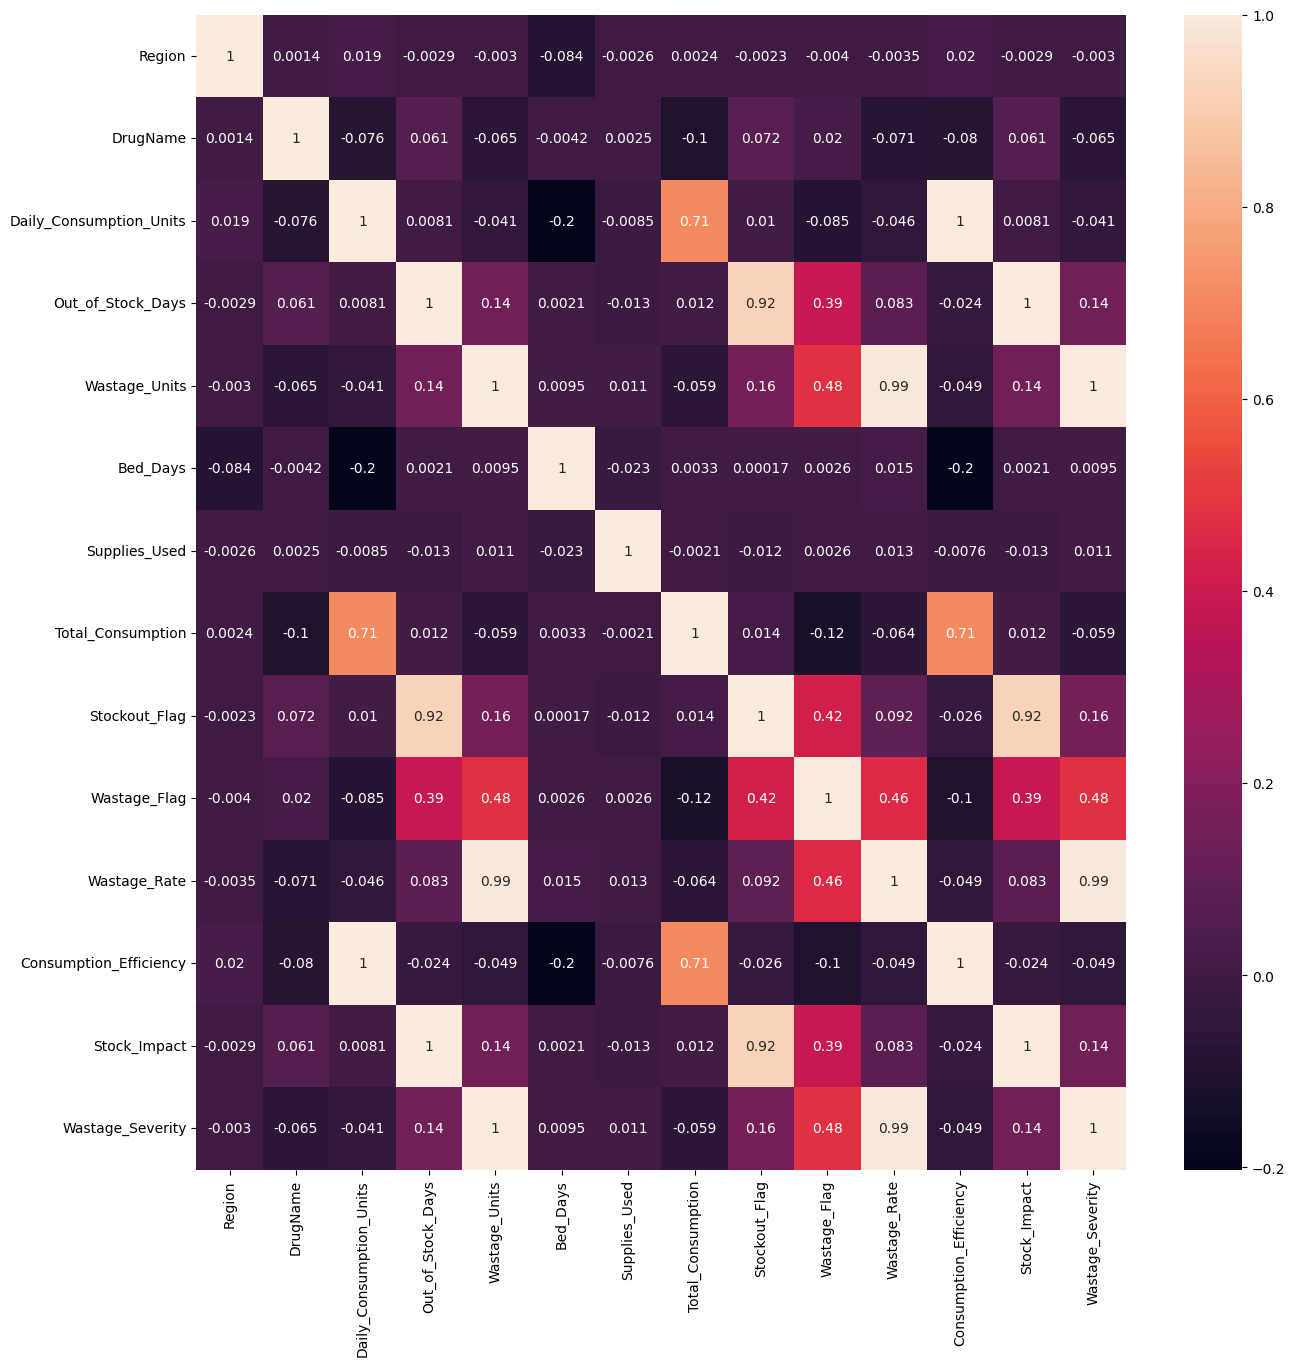

In [12]:
lb.plt.figure(figsize = (15,15))
corr_mat = consumption_ml.corr()
lb.sns.heatmap(corr_mat,annot  = True)

In [13]:
trg_corr = consumption_ml.corr()['Total_Consumption'].sort_values()
trg_corr

Wastage_Flag              -0.118774
DrugName                  -0.100666
Wastage_Rate              -0.063540
Wastage_Units             -0.059195
Wastage_Severity          -0.059195
Supplies_Used             -0.002081
Region                     0.002414
Bed_Days                   0.003334
Out_of_Stock_Days          0.012243
Stock_Impact               0.012243
Stockout_Flag              0.013717
Consumption_Efficiency     0.705608
Daily_Consumption_Units    0.706722
Total_Consumption          1.000000
Name: Total_Consumption, dtype: float64

In [14]:
X = consumption_ml[
    ['Daily_Consumption_Units',
     'Wastage_Flag',
     'DrugName']
]

y = consumption_ml['Total_Consumption']

X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y, test_size=0.2, random_state=42
)

for k in [3, 5, 7, 9, 11]:
    knn = lb.KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    print(f"\nK = {k}")
    print("R2:", lb.r2_score(y_test, y_pred))
    print("MAE:", lb.mean_absolute_error(y_test, y_pred))
    print("MSE:", lb.mean_squared_error(y_test, y_pred))


K = 3
R2: 0.6403846574845673
MAE: 1.4223121907332432
MSE: 29.48338881391513

K = 5
R2: 0.6283868286139823
MAE: 1.3969770580296896
MSE: 30.467041655420605

K = 7
R2: 0.636299328062689
MAE: 1.3595912859070753
MSE: 29.818328238177866

K = 9
R2: 0.617400228464871
MAE: 1.355410606287799
MSE: 31.367787996423477

K = 11
R2: 0.6299672901869176
MAE: 1.34631333578702
MSE: 30.337466085217283


In [15]:
# Features and target
X = consumption_ml[
    ['Daily_Consumption_Units',
     'Wastage_Flag',
     'DrugName']
]

y = consumption_ml['Total_Consumption']

# Split
X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
knn = lb.KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Metrics
print("R2 Score:", lb.r2_score(y_test, y_pred))
print("MAE:", lb.mean_absolute_error(y_test, y_pred))
print("MSE:", lb.mean_squared_error(y_test, y_pred))

R2 Score: 0.6403846574845673
MAE: 1.4223121907332432
MSE: 29.48338881391513


In [16]:
X = consumption_ml[[
       'Daily_Consumption_Units',
    'Consumption_Efficiency',
    'Wastage_Flag',
    'DrugName',
    'Wastage_Rate',
    'Wastage_Severity']]

y = consumption_ml['Total_Consumption']

X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y, test_size=0.2, random_state=42
)

for k in [3, 5, 7, 9, 11]:
    knn = lb.KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    print(f"\nK = {k}")
    print("R2:", lb.r2_score(y_test, y_pred))
    print("MAE:", lb.mean_absolute_error(y_test, y_pred))
    print("MSE:", lb.mean_squared_error(y_test, y_pred))


K = 3
R2: 0.6384743512403364
MAE: 1.4317888738941371
MSE: 29.640006997550856

K = 5
R2: 0.6314082755752688
MAE: 1.3973549257759783
MSE: 30.21932559604139

K = 7
R2: 0.6371387623639556
MAE: 1.3746738641475484
MSE: 29.749506458453823

K = 9
R2: 0.6184558542144649
MAE: 1.3707902234218026
MSE: 31.281241565452095

K = 11
R2: 0.6294455223147712
MAE: 1.3568846358320044
MSE: 30.380243695698237


In [17]:
# Input features and target
X = consumption_ml[['Daily_Consumption_Units', 'DrugName', 'Wastage_Flag']]
y = consumption_ml['Total_Consumption']

# Train-test split
X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train Linear Regression model
lr = lb.LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation metrics
r2 = lb.r2_score(y_test, y_pred)
mae = lb.mean_absolute_error(y_test, y_pred)
mse = lb.mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)

R2 Score: 0.5330385668446163
MAE: 1.8399324998760587
MSE: 38.28425505575416


In [18]:
# Input features and target
X = consumption_ml[
    ['Region',
     'DrugName',
     'Supplies_Used',
     'Daily_Consumption_Units',
     'Out_of_Stock_Days',
     'Wastage_Units',
     'Stockout_Flag',
     'Wastage_Flag']
]

y = consumption_ml['Total_Consumption']

# Train-test split
X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression model
lr = lb.LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation metrics
print("R2 Score:", lb.r2_score(y_test, y_pred))
print("MAE:", lb.mean_absolute_error(y_test, y_pred))
print("MSE:", lb.mean_squared_error(y_test, y_pred))

R2 Score: 0.5337897295491103
MAE: 1.8273494775232995
MSE: 38.222670302656034


In [19]:
# Feature pool (already processed data)
import random
all_features = [
    'Region',
    'DrugName',
    'Daily_Consumption_Units',
    'Out_of_Stock_Days',
    'Wastage_Units',
    'Bed_Days',
    'Supplies_Used',
    'Stockout_Flag',
    'Wastage_Flag',
    'Wastage_Rate',
    #'Consumption_Efficiency',
    'Stock_Impact',
    'Wastage_Severity',
    
]

y = consumption_ml['Total_Consumption']

results = []

for i in range(100):

    # random 5 features
    features = random.sample(all_features, 5)
    X = consumption_ml[features]

    # split
    X_train, X_test, y_train, y_test = lb.train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # KNN model
    model = lb.KNeighborsRegressor(n_neighbors=5)
    model.fit(X_train, y_train)

    # predictions
    y_pred = model.predict(X_test)

    # metrics
    r2 = lb.r2_score(y_test, y_pred)
    mae = lb.mean_absolute_error(y_test, y_pred)
    mse = lb.mean_squared_error(y_test, y_pred)

    results.append([features, r2, mae, mse])

# results dataframe
results_df = lb.pd.DataFrame(results, columns=['Features', 'R2', 'MAE', 'MSE'])

# sort by best R2
results_df = results_df.sort_values(by='R2', ascending=False)

print(results_df.head(10))

                                             Features        R2       MAE  \
1   [Bed_Days, Wastage_Flag, Wastage_Severity, Was...  0.809348  0.285281   
54  [Bed_Days, Wastage_Units, Stockout_Flag, Wasta...  0.809124  0.288664   
85  [Out_of_Stock_Days, Wastage_Flag, Wastage_Rate...  0.809060  0.290967   
30  [Wastage_Severity, Wastage_Flag, Daily_Consump...  0.808940  0.296239   
14  [Daily_Consumption_Units, Stock_Impact, Bed_Da...  0.808281  0.289762   
16  [Daily_Consumption_Units, Bed_Days, DrugName, ...  0.749306  1.047872   
31  [Bed_Days, Wastage_Units, Daily_Consumption_Un...  0.748731  1.044759   
51  [Supplies_Used, DrugName, Bed_Days, Daily_Cons...  0.747625  1.232515   
79  [Bed_Days, Daily_Consumption_Units, DrugName, ...  0.747625  1.232605   
25  [Daily_Consumption_Units, Region, Wastage_Flag...  0.729798  0.662564   

          MSE  
1   15.630749  
54  15.649111  
85  15.654356  
30  15.664264  
14  15.718221  
16  20.553370  
31  20.600483  
51  20.691167  
79  20.6

In [20]:

# All usable features (already processed dataset)
all_features = [
    'Region',
    'DrugName',
    'Daily_Consumption_Units',
    'Out_of_Stock_Days',
    'Wastage_Units',
    'Bed_Days',
    'Supplies_Used',
    'Stockout_Flag',
    'Wastage_Flag',
    'Wastage_Rate',
   # 'Consumption_Efficiency',
    'Stock_Impact',
    'Wastage_Severity',
]

y = consumption_ml['Total_Consumption']
results = []

for i in range(100):  # increase for better search

    # pick random 5 features
    features = random.sample(all_features, 7)
    X = consumption_ml[features]

    # split
    X_train, X_test, y_train, y_test = lb.train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # model
    model = lb.LinearRegression()
    model.fit(X_train, y_train)

    # predictions
    y_pred = model.predict(X_test)

    # metrics
    r2 = lb.r2_score(y_test, y_pred)
    mae = lb.mean_absolute_error(y_test, y_pred)
    mse = lb.mean_squared_error(y_test, y_pred)

    results.append([features, r2, mae, mse])

# results table
results_df = lb.pd.DataFrame(results, columns=['Features', 'R2', 'MAE', 'MSE'])

# sort best models
results_df = results_df.sort_values(by='R2', ascending=False)

print(results_df.head(10))

                                             Features        R2       MAE  \
26  [Supplies_Used, Wastage_Flag, Daily_Consumptio...  0.556090  1.782941   
71  [Wastage_Units, Out_of_Stock_Days, DrugName, D...  0.554976  1.785259   
1   [Stock_Impact, Daily_Consumption_Units, Bed_Da...  0.554976  1.785259   
70  [Supplies_Used, Out_of_Stock_Days, DrugName, D...  0.554701  1.785523   
83  [Stockout_Flag, Daily_Consumption_Units, Bed_D...  0.554644  1.787777   
63  [Bed_Days, DrugName, Supplies_Used, Region, Wa...  0.554644  1.787777   
6   [DrugName, Daily_Consumption_Units, Bed_Days, ...  0.554640  1.787081   
14  [Stock_Impact, DrugName, Stockout_Flag, Wastag...  0.554607  1.784837   
46  [DrugName, Wastage_Severity, Daily_Consumption...  0.554560  1.787584   
3   [Out_of_Stock_Days, Daily_Consumption_Units, R...  0.554538  1.787450   

          MSE  
26  36.394345  
71  36.485690  
1   36.485690  
70  36.508249  
83  36.512921  
63  36.512921  
6   36.513280  
14  36.515949  
46  36.5

In [21]:
# Input features and target
X = consumption_ml[['Stockout_Flag', 'Wastage_Rate', 'Daily_Consumption_Units', 'Bed_Days', 'Wastage_Flag']]
y = consumption_ml['Total_Consumption']

# Train-test split
X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model creation
lr2 = lb.LinearRegression()
lr2.fit(X_train, y_train)

# Predictions
y_pred_lr2 = lr2.predict(X_test)

# Evaluation
print("R2 Score:", lb.r2_score(y_test, y_pred_lr2))
print("MAE:", lb.mean_absolute_error(y_test, y_pred_lr2))
print("MSE:", lb.mean_squared_error(y_test, y_pred_lr2))

R2 Score: 0.5538321928270038
MAE: 1.754548432914306
MSE: 36.57947083992624


In [22]:
# Input features and target
X = consumption_ml[['Stockout_Flag', 'Wastage_Rate', 'Daily_Consumption_Units', 'Bed_Days', 'Wastage_Flag']]
y = consumption_ml['Total_Consumption']

# Train-test split
X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN Regressor
knn = lb.KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

# Predictions
y_pred_knn5 = knn.predict(X_test)

# Evaluation
print("R2 Score:", lb.r2_score(y_test, y_pred_knn5))
print("MAE:", lb.mean_absolute_error(y_test, y_pred_knn5))
print("MSE:", lb.mean_squared_error(y_test, y_pred_knn5))

R2 Score: 0.8097800731973437
MAE: 0.28073774179037336
MSE: 15.595352586594693


## Computing residuals

In [23]:
#Linear Regression

In [24]:
residuals_lr2 = y_test - y_pred_lr2
residuals_lr2

9035    1.598057
5577   -1.081411
4679   -1.075373
8835   -0.312417
6375    7.095974
          ...   
2301   -1.858886
2245   -1.232075
9490    3.535585
6385   -1.232075
8241    3.819658
Name: Total_Consumption, Length: 2223, dtype: float64

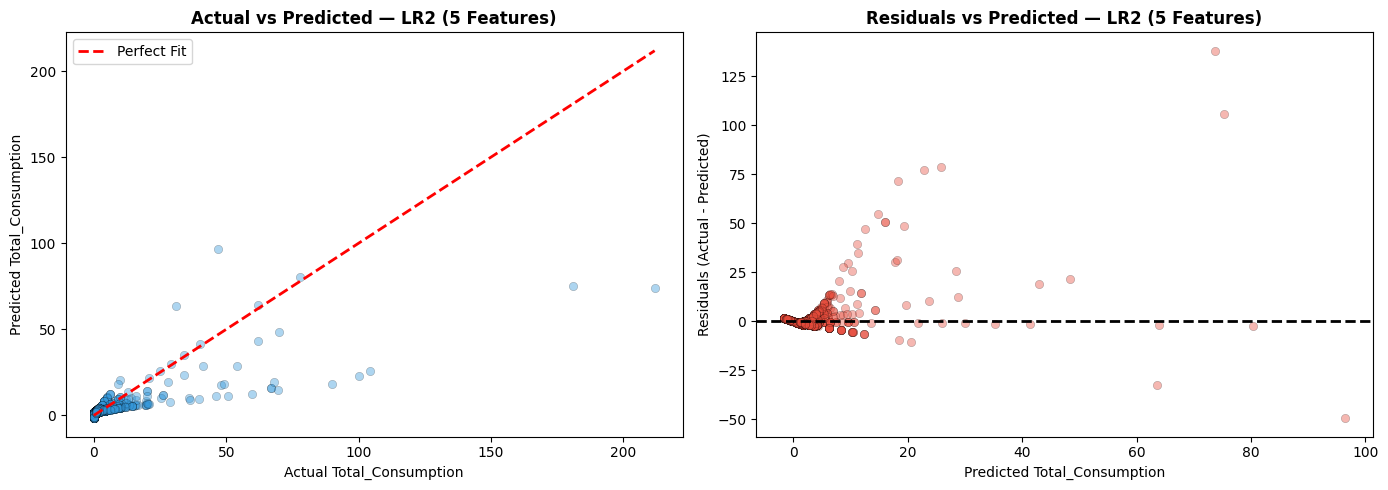

In [25]:
lb.plt.figure(figsize=(14, 5))

lb.plt.subplot(1, 2, 1)
lb.plt.scatter(y_test, y_pred_lr2, alpha=0.4, color='#3498db', edgecolors='k', linewidths=0.3)
lb.plt.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect Fit')
lb.plt.xlabel('Actual Total_Consumption')
lb.plt.ylabel('Predicted Total_Consumption')
lb.plt.title('Actual vs Predicted — LR2 (5 Features)', fontweight='bold')
lb.plt.legend()

lb.plt.subplot(1, 2, 2)
lb.plt.scatter(y_pred_lr2, residuals_lr2, alpha=0.4, color='#e74c3c', edgecolors='k', linewidths=0.3)
lb.plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
lb.plt.xlabel('Predicted Total_Consumption')
lb.plt.ylabel('Residuals (Actual - Predicted)')
lb.plt.title('Residuals vs Predicted — LR2 (5 Features)', fontweight='bold')

lb.plt.tight_layout()
lb.plt.show()

## Residual distribution

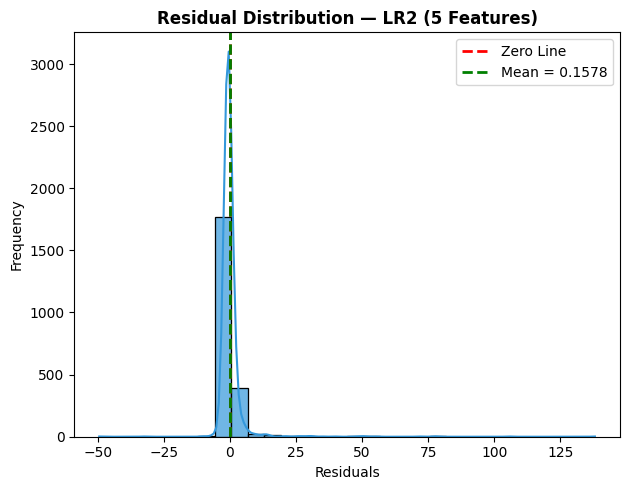

In [26]:
lb.plt.figure(figsize=(12, 5))

lb.plt.subplot(1, 2, 1)
lb.sns.histplot(residuals_lr2, kde=True, bins=30, color='#3498db', alpha=0.7)
lb.plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
lb.plt.axvline(x=residuals_lr2.mean(), color='green', linestyle='--',
               linewidth=2, label=f'Mean = {residuals_lr2.mean():.4f}')
lb.plt.xlabel('Residuals')
lb.plt.ylabel('Frequency')
lb.plt.title('Residual Distribution — LR2 (5 Features)', fontweight='bold')
lb.plt.legend()

lb.plt.tight_layout()
lb.plt.show()

## Predict new data

In [27]:
new_data_lr2 = lb.pd.DataFrame({
    'Stockout_Flag'           : [0,   1,   0],
    'Wastage_Rate'            : [0.0, 0.8, 0.2],
    'Daily_Consumption_Units' : [0.5, 1.2, 0.3],
    'Bed_Days'                : [7,   10,  4  ],
    'Wastage_Flag'            : [0,   1,   0  ]
})

print("Input Data:")
print(new_data_lr2.to_string(index=False))

predictions_lr2 = lr2.predict(new_data_lr2)

print("\nPredictions:")
print("-" * 45)
for i, pred in enumerate(predictions_lr2):
    print(f"  Record {i+1} → Predicted Total_Consumption : {pred:.4f}")

Input Data:
 Stockout_Flag  Wastage_Rate  Daily_Consumption_Units  Bed_Days  Wastage_Flag
             0           0.0                      0.5         7             0
             1           0.8                      1.2        10             1
             0           0.2                      0.3         4             0

Predictions:
---------------------------------------------
  Record 1 → Predicted Total_Consumption : 12.8549
  Record 2 → Predicted Total_Consumption : 19.6286
  Record 3 → Predicted Total_Consumption : 8.7060


In [28]:
#KNN Regressor

In [29]:
residuals_knn5 = y_test - y_pred_knn5
residuals_knn5

9035    0.00
5577    0.00
4679    0.00
8835    0.00
6375   -0.32
        ... 
2301    0.00
2245    0.00
9490    0.72
6385    0.00
8241    0.24
Name: Total_Consumption, Length: 2223, dtype: float64

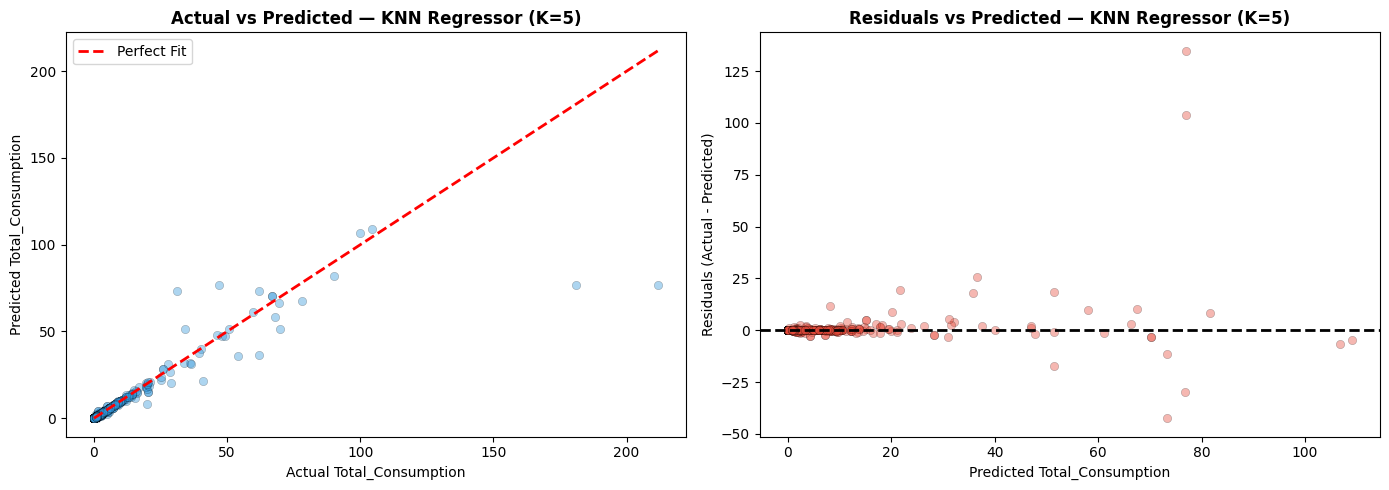

In [30]:
lb.plt.figure(figsize=(14, 5))

lb.plt.subplot(1, 2, 1)
lb.plt.scatter(y_test, y_pred_knn5, alpha=0.4, color='#3498db', edgecolors='k', linewidths=0.3)
lb.plt.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect Fit')
lb.plt.xlabel('Actual Total_Consumption')
lb.plt.ylabel('Predicted Total_Consumption')
lb.plt.title('Actual vs Predicted — KNN Regressor (K=5)', fontweight='bold')
lb.plt.legend()

lb.plt.subplot(1, 2, 2)
lb.plt.scatter(y_pred_knn5, residuals_knn5, alpha=0.4, color='#e74c3c', edgecolors='k', linewidths=0.3)
lb.plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
lb.plt.xlabel('Predicted Total_Consumption')
lb.plt.ylabel('Residuals (Actual - Predicted)')
lb.plt.title('Residuals vs Predicted — KNN Regressor (K=5)', fontweight='bold')

lb.plt.tight_layout()
lb.plt.show()

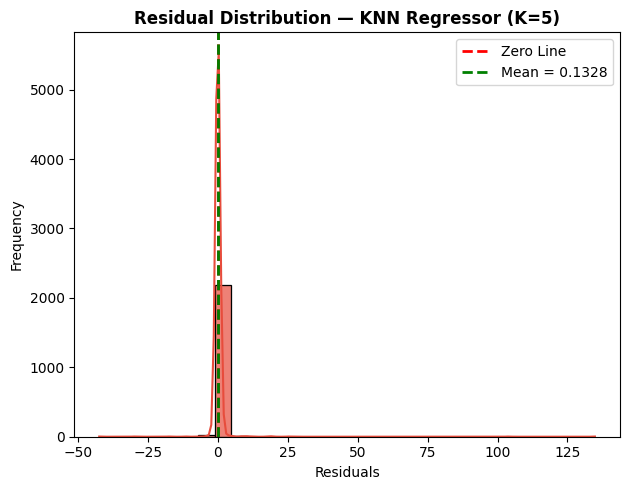

In [31]:
lb.plt.figure(figsize=(12, 5))

lb.plt.subplot(1, 2, 1)
lb.sns.histplot(residuals_knn5, kde=True, bins=30, color='#e74c3c', alpha=0.7)
lb.plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
lb.plt.axvline(x=residuals_knn5.mean(), color='green', linestyle='--',
               linewidth=2, label=f'Mean = {residuals_knn5.mean():.4f}')
lb.plt.xlabel('Residuals')
lb.plt.ylabel('Frequency')
lb.plt.title('Residual Distribution — KNN Regressor (K=5)', fontweight='bold')
lb.plt.legend()

lb.plt.tight_layout()
lb.plt.show()

In [32]:
new_data_knn5 = lb.pd.DataFrame({
    'Stockout_Flag'           : [0,   1,   0],
    'Wastage_Rate'            : [0.0, 0.8, 0.2],
    'Daily_Consumption_Units' : [0.5, 1.2, 0.3],
    'Bed_Days'                : [7,   10,  4  ],
    'Wastage_Flag'            : [0,   1,   0  ]
})

print("Input Data:")
print(new_data_knn5.to_string(index=False))

predictions_knn5 = knn.predict(new_data_knn5)

print("\nPredictions:")
print("-" * 45)
for i, pred in enumerate(predictions_knn5):
    print(f"  Record {i+1} → Predicted Total_Consumption : {pred:.4f}")

Input Data:
 Stockout_Flag  Wastage_Rate  Daily_Consumption_Units  Bed_Days  Wastage_Flag
             0           0.0                      0.5         7             0
             1           0.8                      1.2        10             1
             0           0.2                      0.3         4             0

Predictions:
---------------------------------------------
  Record 1 → Predicted Total_Consumption : 25.7600
  Record 2 → Predicted Total_Consumption : 4.2000
  Record 3 → Predicted Total_Consumption : 17.9200


# Logitic Regression

In [33]:
# Features & Target
X = consumption_data[[
    'Wastage_Flag',
    'Daily_Consumption_Units',
    'Wastage_Units',
    'Bed_Days'
]]

y = consumption_data['Stockout_Flag']

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (11111, 4)
Target Shape  : (11111,)


In [34]:
X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

In [35]:
# Scaling

scaler = lb.StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled  = scaler.transform(X_test)

In [36]:
# Model Training
model_lr = lb.LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [37]:
# Evaluation

y_pred = model_lr.predict(X_test_scaled)
y_pred_prob = model_lr.predict_proba(X_test_scaled)[:, 1]

# Accuracy
print("=" * 45)
print("CLASSIFICATION REPORT")
print("=" * 45)
print(lb.classification_report(y_test, y_pred, target_names=['No Stockout', 'Stockout']))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Stockout       1.00      0.88      0.94      2160
    Stockout       0.20      1.00      0.33        63

    accuracy                           0.88      2223
   macro avg       0.60      0.94      0.63      2223
weighted avg       0.98      0.88      0.92      2223



## Observation

**Accuracy = 88%** model correctly classifies 88% of all records overall.

**Recall = 1.00 for Stockout** model never misses a real stockout event. In medical supply chain this is CRITICAL missing a stockout 
           could risk patient safety.

*Precision = 0.20 for Stockout** model raises many false alarms (80% of stockout predictions are wrong). This means staff may waste time 
             investigating non-issues. 

**Class Imbalance Issue** only 63 stockout cases vs 2160 non-stockout cases (97:3 ratio)model is biased toward majority class.

**Key Insight:**  

HIGH RECALL is more important than precision, it's better to over-alert than miss a real stockout that impacts patient care.

In [38]:
# Confusion Matrix
print("Confusion Matrix:")
cm = lb.confusion_matrix(y_test, y_pred)
print(cm)

lb.plt.figure(figsize=(14, 5))

Confusion Matrix:
[[1900  260]
 [   0   63]]


<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

Text(50.72222222222221, 0.5, 'Actual')

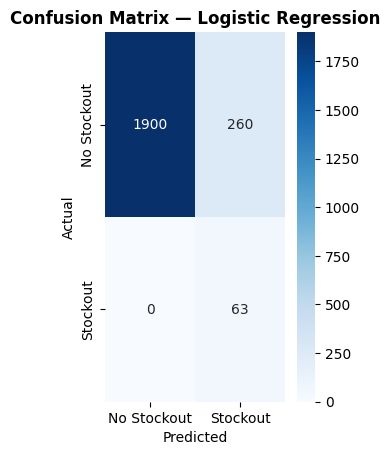

In [39]:
lb.plt.subplot(1, 2, 1)
lb.sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['No Stockout', 'Stockout'],
               yticklabels=['No Stockout', 'Stockout'])
lb.plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
lb.plt.xlabel('Predicted')
lb.plt.ylabel('Actual')

## Observation

**FN = 0** model missed ZERO real stockouts perfect recall for critical class. 
       In medical supply chain this is the most important metric no patient was at risk due to missed stockout prediction.

**FP = 260** 260 false alarms raised staff would investigate unnecessarily. Acceptable trade-off in healthcare where missing a stockout is far 
             more dangerous than a false alarm.

**TN = 1900** 1900 non-stockout cases correctly identified.

**Key Insight:** 
Zero False Negatives makes this model medically safe it never fails to detect a real stockout event.

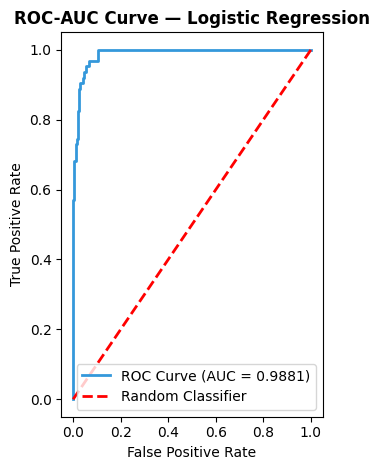


ROC-AUC Score : 0.9881


In [40]:
#  ROC-AUC Curve
lb.plt.subplot(1, 2, 2)
fpr, tpr, thresholds = lb.roc_curve(y_test, y_pred_prob)
auc_score = lb.roc_auc_score(y_test, y_pred_prob)
lb.plt.plot(fpr, tpr, color='#3498db', linewidth=2,
            label=f'ROC Curve (AUC = {auc_score:.4f})')
lb.plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
lb.plt.xlabel('False Positive Rate')
lb.plt.ylabel('True Positive Rate')
lb.plt.title('ROC-AUC Curve — Logistic Regression', fontweight='bold')
lb.plt.legend()

lb.plt.tight_layout()
lb.plt.show()

print(f"\nROC-AUC Score : {auc_score:.4f}")

## Observations

**AUC = 0.9881** excellent score! Model has 98.81% ability to distinguish between Stockout and No Stockout.

**Curve hugs top-left corner** ideal shape indicating strong classifier. 

**Far above random classifier (red line)** model is significantly better than random guessing.

**Business Observation:**

AUC of 0.99 means the model can reliably rank stockout risk supply chain managers can use this to prioritize which medicines 
       need immediate restocking attention.

**Key Insight:** 

Despite class imbalance (only 2.8% stockout cases), the model achieves near-perfect discrimination Wastage_Flag is an extremely powerful 
redictor of Stockout.

In [41]:
# Predict New Data
# Features used: Wastage_Flag, Daily_Consumption_Units, Wastage_Units, Bed_Days

new_data = lb.pd.DataFrame({
    'Wastage_Flag'            : [0,   1,   0],
    'Daily_Consumption_Units' : [0.3, 1.5, 0.8],
    'Wastage_Units'           : [0,   5,   1],
    'Bed_Days'                : [4,   10,  7]
})

print("Input Data:")
print(new_data.to_string(index=False))

# Scale using same scaler
new_data_scaled = scaler.transform(new_data)

# Predict
predictions      = model_lr.predict(new_data_scaled)
predictions_prob = model_lr.predict_proba(new_data_scaled)[:, 1]

print("\nPredictions:")
print("-" * 55)
for i in range(len(new_data)):
    status = "STOCKOUT" if predictions[i] == 1 else "No Stockout"
    print(f"  Record {i+1} → {status} | Probability: {predictions_prob[i]:.4f}")

Input Data:
 Wastage_Flag  Daily_Consumption_Units  Wastage_Units  Bed_Days
            0                      0.3              0         4
            1                      1.5              5        10
            0                      0.8              1         7

Predictions:
-------------------------------------------------------
  Record 1 → No Stockout | Probability: 0.0000
  Record 2 → STOCKOUT | Probability: 0.9354
  Record 3 → No Stockout | Probability: 0.0000


## Observations

**Record 1 (P=0.000)** No wastage, low consumption, short stay, Zero stockout risk. Routine patient, medicine well managed.

**Record 2 (P=0.935)** Wastage present, high consumption, long stay 93.5% stockout probability. HIGH RISK patient immediate restocking action needed.

**Record 3 (P=0.000)** No wastage flag despite some wastage units model treats it as safe. Moderate risk patient.

**Business Observation:**

Wastage_Flag = 1 is the strongest trigger for stockout prediction. Any medicine showing wastage should be flagged for immediate inventory review.

**Key Insight:** 
                                                                                                                  
Model gives clear binary actionable output supply chain teams can act immediately on STOCKOUT predictions.

# KNN(K Nearest Neighbors)

In [42]:
# Features & Target
X = consumption_data[[
    'Wastage_Flag',
    'Daily_Consumption_Units',
    'Wastage_Units',
    'Bed_Days'
]]

y = consumption_data['Stockout_Flag']

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (11111, 4)
Target Shape  : (11111,)


In [43]:
# Train-Test Split
X_train, X_test, y_train, y_test = lb.train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (8888, 4)
Test Shape  : (2223, 4)


In [44]:
# Scaling 
scaler = lb.MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(X_train_scaled)
print(X_test_scaled)

[[0.00000000e+00 6.99300699e-04 0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 6.99300699e-04 0.00000000e+00 6.15384615e-01]
 [1.00000000e+00 0.00000000e+00 4.00000000e-02 1.00000000e+00]
 ...
 [0.00000000e+00 2.79720280e-03 0.00000000e+00 3.07692308e-01]
 [1.00000000e+00 0.00000000e+00 2.00000000e-02 3.07692308e-01]
 [0.00000000e+00 6.99300699e-04 0.00000000e+00 6.15384615e-01]]
[[0.00000000e+00 6.99300699e-04 0.00000000e+00 9.23076923e-01]
 [0.00000000e+00 4.89510490e-03 0.00000000e+00 1.53846154e-01]
 [0.00000000e+00 6.99300699e-04 0.00000000e+00 8.46153846e-01]
 ...
 [0.00000000e+00 4.89510490e-03 0.00000000e+00 1.53846154e-01]
 [0.00000000e+00 2.09790210e-03 0.00000000e+00 1.00000000e+00]
 [1.00000000e+00 0.00000000e+00 2.00000000e-01 4.61538462e-01]]


In [45]:
# Find Optimal K
error_rate = []
k_range = range(1, 31)

for k in k_range:
    knn = lb.KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    error_rate.append(1 - lb.accuracy_score(y_test, y_pred_k))

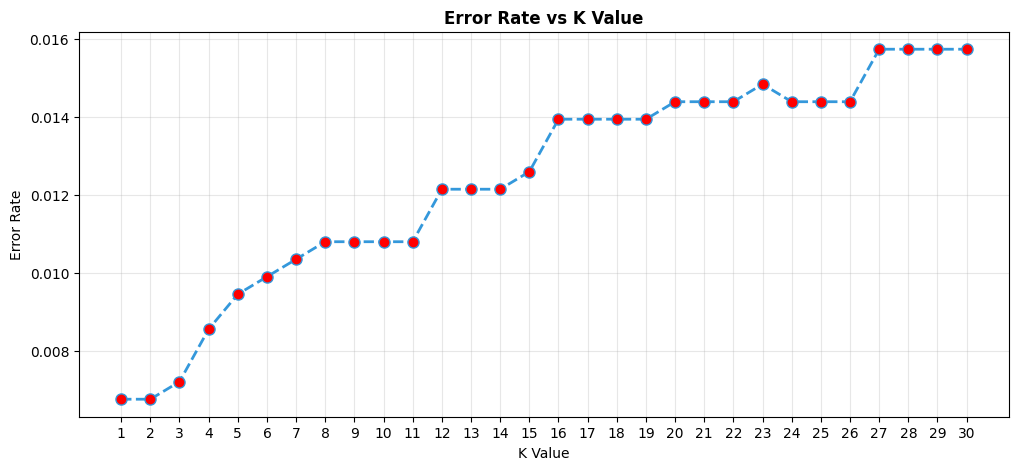

In [46]:
# Plot Error Rate vs K
lb.plt.figure(figsize=(12, 5))
lb.plt.plot(k_range, error_rate, color='#3498db', 
            linestyle='--', marker='o', markerfacecolor='red',
            markersize=8, linewidth=2)
lb.plt.xlabel('K Value')
lb.plt.ylabel('Error Rate')
lb.plt.title('Error Rate vs K Value', fontweight='bold')
lb.plt.xticks(k_range)
lb.plt.grid(True, alpha=0.3)
lb.plt.show()

In [47]:
optimal_k = 3
print(f"Selected K : {optimal_k}" )

Selected K : 3


In [48]:
# Model Training
model_knn = lb.KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',   
    metric='euclidean'     
)

model_knn.fit(X_train_scaled, y_train)
print("KNN Model Trained Successfully!")

KNN Model Trained Successfully!


In [49]:
# Evaluation
y_pred = model_knn.predict(X_test_scaled)
y_pred_prob = model_knn.predict_proba(X_test_scaled)[:, 1]

In [50]:
# Classification Report
print("=" * 45)
print("CLASSIFICATION REPORT")
print("=" * 45)
print(lb.classification_report(y_test, y_pred, target_names=['No Stockout', 'Stockout']))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Stockout       0.99      1.00      1.00      2160
    Stockout       0.98      0.76      0.86        63

    accuracy                           0.99      2223
   macro avg       0.99      0.88      0.93      2223
weighted avg       0.99      0.99      0.99      2223



In [51]:
# Confusion Matrix
print("Confusion Matrix:")
cm = lb.confusion_matrix(y_test, y_pred)
print(cm)

lb.plt.figure(figsize=(14, 5))

Confusion Matrix:
[[2159    1]
 [  15   48]]


<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

Text(50.72222222222221, 0.5, 'Actual')

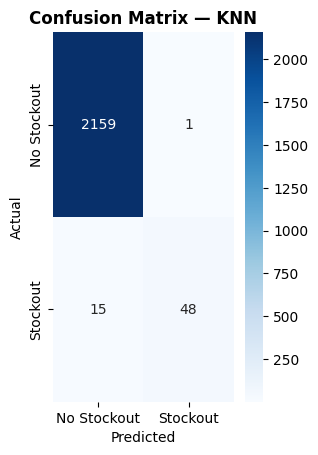

In [52]:
# Confusion Matrix Heatmap
lb.plt.subplot(1, 2, 1)
lb.sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['No Stockout', 'Stockout'],
               yticklabels=['No Stockout', 'Stockout'])
lb.plt.title('Confusion Matrix — KNN', fontweight='bold')
lb.plt.xlabel('Predicted')
lb.plt.ylabel('Actual')

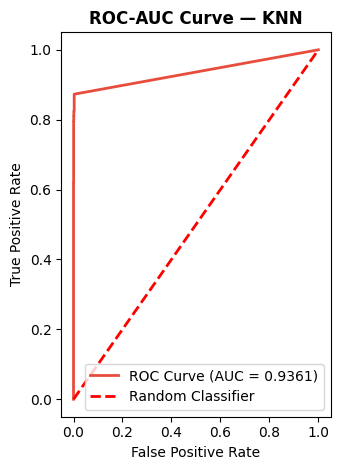


ROC-AUC Score : 0.9361


In [53]:
# ROC-AUC Curve
lb.plt.subplot(1, 2, 2)
fpr, tpr, thresholds = lb.roc_curve(y_test, y_pred_prob)
auc_score = lb.roc_auc_score(y_test, y_pred_prob)
lb.plt.plot(fpr, tpr, color='#e74c3c', linewidth=2,
            label=f'ROC Curve (AUC = {auc_score:.4f})')
lb.plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
lb.plt.xlabel('False Positive Rate')
lb.plt.ylabel('True Positive Rate')
lb.plt.title('ROC-AUC Curve — KNN', fontweight='bold')
lb.plt.legend()

lb.plt.tight_layout()
lb.plt.show()

print(f"\nROC-AUC Score : {auc_score:.4f}")

In [54]:
# Predict New Data - KNN
# Features used: Wastage_Flag, Daily_Consumption_Units, Wastage_Units, Bed_Days

new_data = lb.pd.DataFrame({
    'Wastage_Flag'            : [0,   1,   0],
    'Daily_Consumption_Units' : [0.3, 1.5, 0.8],
    'Wastage_Units'           : [0,   5,   1],
    'Bed_Days'                : [4,   10,  7]
})

print("Input Data:")
print(new_data.to_string(index=False))

# Scale using same scaler
new_data_scaled = scaler.transform(new_data)

# Predict
predictions      = model_knn.predict(new_data_scaled)
predictions_prob = model_knn.predict_proba(new_data_scaled)[:, 1]

print("\nPredictions:")
print("-" * 55)
for i in range(len(new_data)):
    status = "STOCKOUT" if predictions[i] == 1 else "No Stockout "
    print(f"  Record {i+1} → {status} | Probability: {predictions_prob[i]:.4f}")

Input Data:
 Wastage_Flag  Daily_Consumption_Units  Wastage_Units  Bed_Days
            0                      0.3              0         4
            1                      1.5              5        10
            0                      0.8              1         7

Predictions:
-------------------------------------------------------
  Record 1 → No Stockout  | Probability: 0.0000
  Record 2 → STOCKOUT | Probability: 0.7200
  Record 3 → No Stockout  | Probability: 0.0000


# KMEANS Clustering

In [55]:
supplier_data = lb.pd.read_csv("Dataset/supplier_procurement_cleaned.csv")
supplier_data.head()

,Supplier_ID,Supplier_Name,Region,Avg_Lead_Time_Days,Reliability_Score,Cost_Per_Item,Last_Order_Date,Next_Delivery_Date,On_Time_Delivery_Rate,Delay_Risk,Reliability_Level,Poor_Performance,Efficiency_Score,Delivery_Gap_Days
0,V923,Supplier_1,Delhi,12,4.2,116.21,2024-01-19,2024-01-31,75,True,High,False,6.250000,12
1,V775,Supplier_2,Delhi,9,4.6,113.26,2024-11-14,2024-11-23,73,False,High,True,8.111111,9
2,V307,Supplier_3,Pune,8,4.1,118.98,2024-09-18,2024-09-26,80,False,High,False,10.000000,8
3,V270,Supplier_4,Pune,9,3.8,103.85,2024-05-24,2024-06-02,71,False,Low,True,7.888889,9
4,V711,Supplier_5,Pune,12,4.4,112.12,2024-08-10,2024-08-22,71,True,High,True,5.916667,12


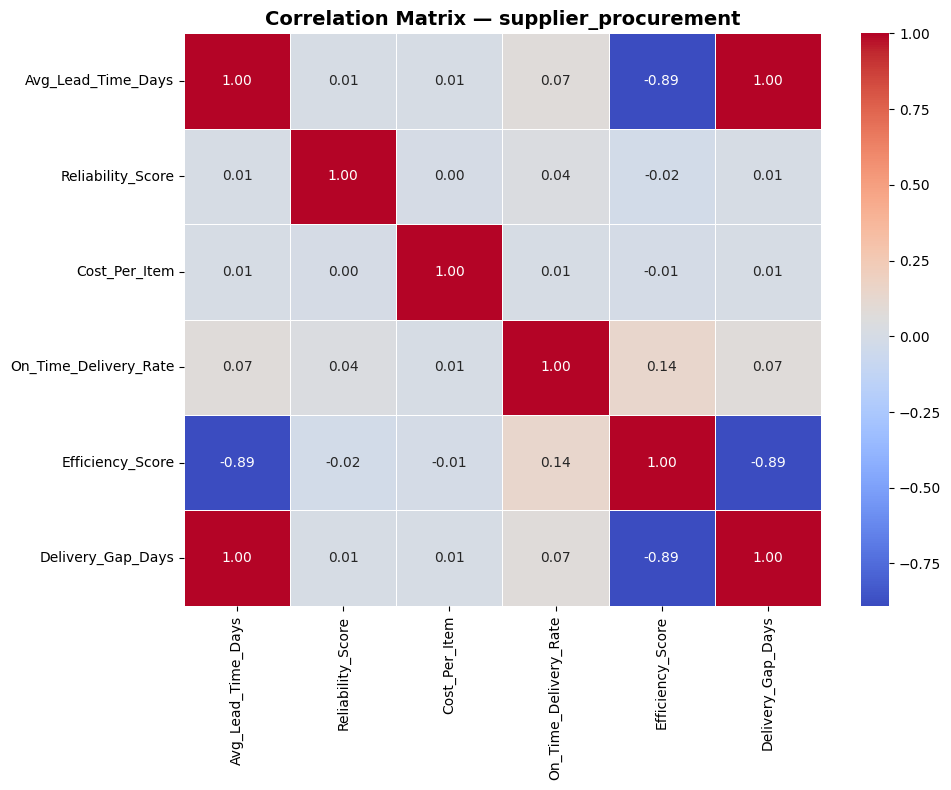

In [56]:
# Correlation Heatmap
lb.plt.figure(figsize=(10, 8))
lb.sns.heatmap(
    supplier_data.select_dtypes(include=['int64', 'float64']).corr().round(2),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
lb.plt.title('Correlation Matrix — supplier_procurement',
             fontsize=14, fontweight='bold')
lb.plt.tight_layout()
lb.plt.show()

In [57]:
# Label Encoding
supplier_ml = supplier_data.copy()

le = lb.LabelEncoder()
supplier_ml['Region'] = le.fit_transform(supplier_ml['Region'])

print("\nRegion encoded:")
print(supplier_ml['Region'].value_counts())
print("\nRegion mapping:")
for i, region in enumerate(le.classes_):
    print(f"  {region} → {i}")


Region encoded:
Region
6    79
2    72
0    72
5    72
7    67
1    62
3    59
4    55
Name: count, dtype: int64

Region mapping:
  Bangalore → 0
  Chennai → 1
  Delhi → 2
  Hyderabad → 3
  Kolkata → 4
  Lucknow → 5
  Mumbai → 6
  Pune → 7


In [58]:
supplier_ml.columns

Index(['Supplier_ID', 'Supplier_Name', 'Region', 'Avg_Lead_Time_Days',
       'Reliability_Score', 'Cost_Per_Item', 'Last_Order_Date',
       'Next_Delivery_Date', 'On_Time_Delivery_Rate', 'Delay_Risk',
       'Reliability_Level', 'Poor_Performance', 'Efficiency_Score',
       'Delivery_Gap_Days'],
      dtype='object')

KeyError: 'Cluster'

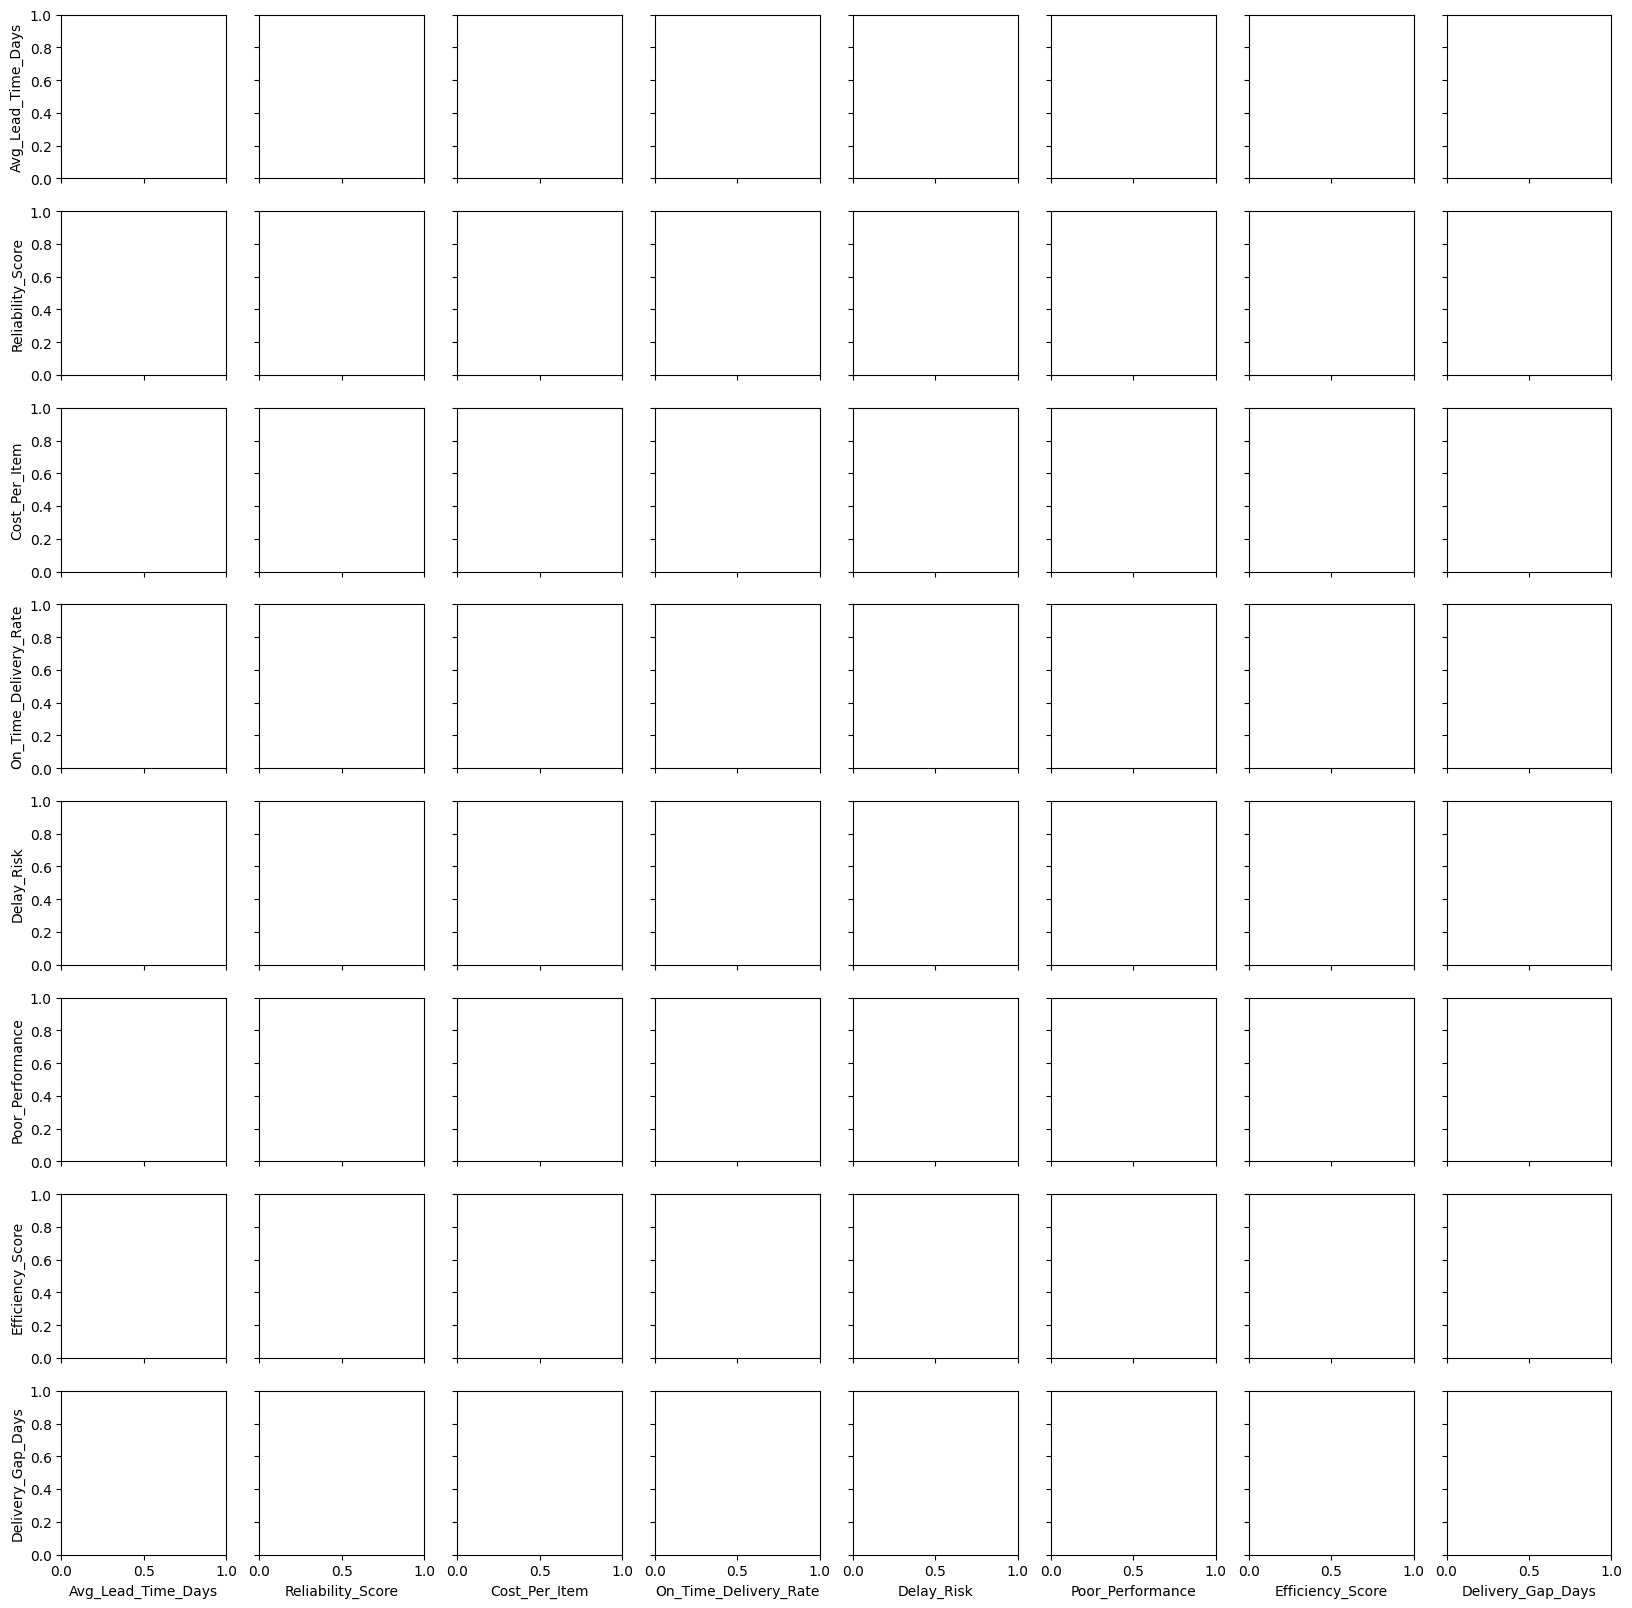

In [59]:
lb.sns.pairplot(supplier_data,hue = 'Cluster')

In [ ]:
features = [
    'Efficiency_Score',
    'Delivery_Gap_Days'
]
X_cluster = supplier_ml[features]
print("Feature Shape :", X_cluster.shape)

In [ ]:
scaler_km = lb.MinMaxScaler()
X_cluster_scaled = scaler_km.fit_transform(X_cluster)
X_cluster_scaled = lb.pd.DataFrame(X_cluster_scaled, columns=X_cluster.columns)

In [ ]:
# Finding Optimal K — Elbow + Silhouette + CH + DB
inertia    = []
silhouette = []
calinski   = []
davies     = []
k_range    = range(2, 11)

for k in k_range:
    kmeans = lb.KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(lb.silhouette_score(X_cluster_scaled, kmeans.labels_))
    calinski.append(lb.calinski_harabasz_score(X_cluster_scaled, kmeans.labels_))
    davies.append(lb.davies_bouldin_score(X_cluster_scaled, kmeans.labels_))

print(f"{'K':<5} {'Inertia':>10} {'Silhouette':>12} {'Calinski':>12} {'Davies':>10}")
print("-" * 55)
for k, i, s, c, d in zip(k_range, inertia, silhouette, calinski, davies):
    print(f"{k:<5} {i:>10.2f} {s:>12.4f} {c:>12.2f} {d:>10.4f}")

In [ ]:
# Elbow + Silhouette Plot
lb.plt.figure(figsize=(14, 5))

lb.plt.subplot(1, 2, 1)
lb.plt.plot(k_range, inertia, color='#3498db',
            linestyle='--', marker='o', markerfacecolor='red',
            markersize=8, linewidth=2)
lb.plt.xlabel('K Value')
lb.plt.ylabel('Inertia')
lb.plt.title('Elbow Method', fontweight='bold')
lb.plt.xticks(k_range)
lb.plt.grid(True, alpha=0.3)

lb.plt.subplot(1, 2, 2)
lb.plt.plot(k_range, silhouette, color='#e74c3c',
            linestyle='--', marker='o', markerfacecolor='blue',
            markersize=8, linewidth=2)
lb.plt.xlabel('K Value')
lb.plt.ylabel('Silhouette Score')
lb.plt.title('Silhouette Score vs K', fontweight='bold')
lb.plt.xticks(k_range)
lb.plt.grid(True, alpha=0.3)

lb.plt.tight_layout()
lb.plt.show()

In [ ]:
# Silhouette Visualization — update K_OPTIMAL after checking table
K_OPTIMAL = 3

fig, ax1 = lb.plt.subplots(1, 1, figsize=(10, 7))
ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X_cluster_scaled) + (K_OPTIMAL + 1) * 10])

clusterer      = lb.KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
cluster_labels = clusterer.fit_predict(X_cluster_scaled)

silhouette_avg           = lb.silhouette_score(X_cluster_scaled, cluster_labels)
sample_silhouette_values = lb.silhouette_samples(X_cluster_scaled, cluster_labels)

y_lower = 10
for i in range(K_OPTIMAL):
    ith_vals = sample_silhouette_values[cluster_labels == i]
    ith_vals.sort()
    y_upper = y_lower + ith_vals.shape[0]
    color = lb.cm.nipy_spectral(float(i) / K_OPTIMAL)
    ax1.fill_betweenx(lb.np.arange(y_lower, y_upper), 0, ith_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * ith_vals.shape[0], str(i),
             fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax1.set_xlabel("Silhouette Coefficient Values")
ax1.set_ylabel("Cluster Label")
ax1.set_title(f"Silhouette Plot — KMeans (K={K_OPTIMAL})\nAvg Score = {silhouette_avg:.4f}",
              fontweight='bold')
ax1.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2,
            label=f'Avg = {silhouette_avg:.4f}')
ax1.set_yticks([])
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
ax1.legend(loc='upper right')
lb.plt.tight_layout()
lb.plt.show()

print(f"Average Silhouette Score (K={K_OPTIMAL}) : {silhouette_avg:.4f}")

In [ ]:
# Final Model — K=3
kmeans = lb.KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_cluster_scaled)
supplier_data['Cluster'] = kmeans.labels_

print(supplier_data.groupby('Cluster')[features].mean().round(3))

In [ ]:
# Assign Cluster Names — update after seeing mean values above
cluster_names = {
    0: "Moderate Performance Suppliers",
    1: "High Performance Suppliers",
    2: "Low Performance Suppliers"
}
supplier_data['Cluster_Name'] = supplier_data['Cluster'].map(cluster_names)

print("Cluster distribution:")
print(supplier_data[['Cluster', 'Cluster_Name']].value_counts().sort_index())

In [ ]:
# Cluster Scores
print(f"Silhouette Score     : {round(lb.silhouette_score(X_cluster_scaled, kmeans.labels_), 4)}")
print(f"Davies-Bouldin Score : {lb.davies_bouldin_score(X_cluster_scaled, kmeans.labels_):.4f}")
print(f"Calinski-Harabasz    : {lb.calinski_harabasz_score(X_cluster_scaled, kmeans.labels_):.4f}")

In [ ]:
# Scatter Plot — Efficiency_Score vs Delivery_Gap_Days
mycolors = ["#f39c12", "#2ecc71", "#e74c3c"]
segments = list(cluster_names.values())

lb.plt.figure(figsize=(12, 6))

for i in range(K_OPTIMAL):
    lb.plt.scatter(
        supplier_data.loc[supplier_data['Cluster'] == i, 'Efficiency_Score'],
        supplier_data.loc[supplier_data['Cluster'] == i, 'Delivery_Gap_Days'],
        c=mycolors[i], label=segments[i], alpha=0.5, s=20
    )

lb.plt.title('KMeans Clustering (Efficiency Score vs Delivery Gap Days)',
             fontweight='bold', fontsize=14)
lb.plt.xlabel('Efficiency Score')
lb.plt.ylabel('Delivery Gap Days')
lb.plt.legend(loc='upper right')
lb.plt.tight_layout()
lb.plt.show()

In [ ]:
# Cluster Profiling
print("=" * 55)
print("CLUSTER PROFILES (Mean Values)")
print("=" * 55)
print(supplier_data.groupby('Cluster_Name')[features].mean().round(3))

In [ ]:
# ============================================================
# CLUSTER INTERPRETATION & BUSINESS INSIGHTS (K=3)
# ============================================================

cluster_names = {
    2: "Low Performance Suppliers",
    0: "Moderate Performance Suppliers",
    1: "High Performance Suppliers"
}

supplier_data['Cluster_Name'] = supplier_data['Cluster'].map(cluster_names)

print("=" * 55)
print("CLUSTER INTERPRETATION")
print("=" * 55)

for cluster, name in cluster_names.items():
    data = supplier_data[supplier_data['Cluster'] == cluster]
    print(f"\nCluster {cluster} → {name}")
    print("-" * 45)
    print(f"  Size                    : {len(data)} records")
    print(f"  Avg Efficiency Score    : {data['Efficiency_Score'].mean():.3f}")
    print(f"  Avg Delivery Gap (Days) : {data['Delivery_Gap_Days'].mean():.3f}")

print("\n" + "=" * 55)
print("BUSINESS INSIGHTS")
print("=" * 55)
print("""
Cluster — High Performance Suppliers:
  → High efficiency score, low delivery gap
  → Preferred vendors for critical medicine procurement
  → Maintain and strengthen contracts with these suppliers (BO2)

Cluster — Moderate Performance Suppliers:
  → Average efficiency, moderate delivery gap
  → Suitable for routine procurement needs
  → Monitor KPIs and push for lead time improvement (BO2 & BO4)

Cluster — Low Performance Suppliers:
  → Low efficiency score, high delivery gap
  → High risk to supply chain continuity
  → Reduce dependency or replace these vendors (BO4)
""")